# Differentially Private DNN (DP-DNN) - Cancer Risk Dataset

This notebook trains a Differentially Private DNN using **Opacus (DP-SGD)** on the Cancer Risk dataset.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print(f"Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Opacus version: {__import__('opacus').__version__}")
print(f"Device: {device}")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


W0810 11:37:55.271000 41923 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Using CPU
PyTorch version: 2.11.0
Opacus version: 1.6.0
Device: cpu


## 2. Load Preprocessed Data

In [2]:
with open("../data/processed_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

X_train = loaded_data["X_train"]
X_test = loaded_data["X_test"]
y_train = loaded_data["y_train"]
y_test = loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Adaptive DP-SGD batch size (D13): scales with training-set size,
# clamped to [16, 256] so small datasets keep enough steps per epoch
# and large ones stay within Opacus' preferred large-batch regime.
n_train = X_train.shape[0]
batch_size = min(256, max(16, n_train // 8))
print(f"[D13] CANCER_RISK: n_train={n_train} -> batch_size={batch_size}")
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaded and prepared")

Training set: (1200, 8)
Test set: (300, 8)
Number of features: 8
[D13] CANCER_RISK: n_train=1200 -> batch_size=150

Data loaded and prepared


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('output/baseline_dnn_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print(f"Baseline results loaded")
    print(f"  Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"  Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("output/baseline_dnn_results.csv not found - run STD_DNN.ipynb first")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded
  Baseline Accuracy: 0.8832
  Baseline F1-Score: 0.8394


## 4. Define DP-Compatible Neural Network

In [4]:
class DPDNNClassifier(nn.Module):
    def __init__(self, input_size=8, hidden_sizes=[64, 32], num_classes=2, dropout=0.3):
        super(DPDNNClassifier, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

input_size = X_train.shape[1]
hidden_sizes = [64, 32]
num_classes = 2
dropout = 0.3
learning_rate = 0.001
num_epochs = 50

print(f"DP-DNN Architecture:")
print(f"  Input: {input_size}")
print(f"  Hidden: {hidden_sizes}")
print(f"  Output: {num_classes}")
print(f"  Dropout: {dropout}")

DP-DNN Architecture:
  Input: 8
  Hidden: [64, 32]
  Output: 2
  Dropout: 0.3


## 5. Training Functions

In [5]:
def train_dp_model(model, train_loader, criterion, optimizer, privacy_engine, num_epochs, device, delta, verbose=False):
    model.train()
    train_losses = []
    epsilons = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        epsilon = privacy_engine.get_epsilon(delta=delta)
        epsilons.append(epsilon)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, \u03b5: {epsilon:.2f}")
    return train_losses, epsilons

def evaluate_model(model, loader, device):
    """Return (labels, predictions, class probabilities) for `loader`.

    The probabilities are what AUROC needs; predictions and labels are
    unchanged from the original implementation.
    """
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
            all_preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("Training functions defined")

Training functions defined


## 6. Privacy Parameters

In [6]:
N_RUNS = 30
max_grad_norm = 1.0
delta = 1e-5

epsilon_values = [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]

print(f"Privacy Configuration:")
print(f"  N_RUNS per epsilon: {N_RUNS}")
print(f"  Max gradient norm: {max_grad_norm}")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Epochs: {num_epochs}")
print(f"  Epsilon values: {epsilon_values}")

Privacy Configuration:
  N_RUNS per epsilon: 30
  Max gradient norm: 1.0
  Training samples: 1200
  Epochs: 50
  Epsilon values: [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]


## 7. Train DP-DNN Across Multiple Epsilon Values

In [7]:
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'recall_mean': [],
}

print(f"Training DP-DNN across {len(epsilon_values)} epsilon values ({N_RUNS} runs each)...")
print("="*80)

# Raw per-run values per epsilon, so the JSON report can record them
# alongside the aggregates (the CSV keeps only the aggregates).
per_run_records = {}

for target_eps in epsilon_values:
    run_accs, run_f1s, run_precisions, run_recalls = [], [], [], []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)

        train_loader_temp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        model = DPDNNClassifier(input_size, hidden_sizes, num_classes, dropout).to(device)
        model = ModuleValidator.fix(model)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        privacy_engine = PrivacyEngine()
        model, optimizer, train_loader_temp = privacy_engine.make_private_with_epsilon(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader_temp,
            target_epsilon=target_eps,
            target_delta=delta,
            epochs=num_epochs,
            max_grad_norm=max_grad_norm,
        )

        if isinstance(optimizer.noise_multiplier, list):
            optimizer.noise_multiplier = optimizer.noise_multiplier[0]

        _t0 = time.perf_counter()
        train_losses, epsilons = train_dp_model(
            model, train_loader_temp, criterion, optimizer, privacy_engine,
            num_epochs, device, delta
        )
        train_time = time.perf_counter() - _t0

        y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)

        run_accs.append(accuracy_score(y_true, y_pred))
        extra.add(y_true, y_pred, y_score=y_prob, train_time=train_time)
        run_f1s.append(f1_score(y_true, y_pred, zero_division=0))
        run_precisions.append(precision_score(y_true, y_pred, zero_division=0))
        run_recalls.append(recall_score(y_true, y_pred, zero_division=0))
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(model, f'output/model/dp_dnn_model_eps_{target_eps}.pkl')

    acc_mean, acc_std = np.mean(run_accs), np.std(run_accs)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)

    results['epsilon'].append(target_eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(np.mean(run_precisions))
    results['recall_mean'].append(np.mean(run_recalls))

    per_run_records[float(target_eps)] = {
        'n_runs': N_RUNS,
        'per_run_accuracies': [float(_v) for _v in run_accs],
        'per_run_f1s': [float(_v) for _v in run_f1s],
        'per_run_precisions': [float(_v) for _v in run_precisions],
        'per_run_recalls': [float(_v) for _v in run_recalls],
        **extra.per_run(),
    }

    print(f"  ε={target_eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | F1: {f1_mean:.4f}±{f1_std:.4f}")

print("="*80)
print("Training complete")

Training DP-DNN across 9 epsilon values (30 runs each)...


PyTorch model successfully exported to output/model/dp_dnn_model_eps_0.1.pkl


  ε=  0.1 | Acc: 0.6212±0.0626 | F1: 0.1717±0.2125


PyTorch model successfully exported to output/model/dp_dnn_model_eps_0.2.pkl


  ε=  0.2 | Acc: 0.6392±0.0233 | F1: 0.0507±0.1306


...

  ε=  4.0 | Acc: 0.7263±0.0352 | F1: 0.4127±0.1284


PyTorch model successfully exported to output/model/dp_dnn_model_eps_8.0.pkl


  ε=  8.0 | Acc: 0.8128±0.0160 | F1: 0.6939±0.0393


PyTorch model successfully exported to output/model/dp_dnn_model_eps_10.0.pkl


  ε= 10.0 | Acc: 0.8267±0.0134 | F1: 0.7297±0.0286
Training complete


## 8. Results Summary

In [8]:
results_df = pd.DataFrame(results)

if baseline_accuracy is not None:
    results_df['ACL'] = 1 - (results_df['accuracy_mean'] / baseline_accuracy)
    results_df['accuracy_loss_pct'] = results_df['ACL'] * 100

print("\n" + "="*80)
print("DP-DNN RESULTS SUMMARY (CANCER RISK DATASET)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


DP-DNN RESULTS SUMMARY (CANCER RISK DATASET)
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  recall_mean  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std      ACL  accuracy_loss_pct
     0.1       0.621222      0.062565       0.171681      0.212453        0.317381     0.177477                0.529656               0.050775      0.639608     0.118550         0.987100        0.022877 0.296641          29.664109
     0.2       0.639222      0.023265       0.050706      0.130610        0.246308     0.036937                0.514941               0.041343      0.727856     0.091835         1.015899        0.026966 0.276261          27.626116
     0.4       0.630444      0.001663       0.002360      0.008830        0.066667     0.001201                0.500601               0.002247      0.796544     0.056883         1.128365        0.165319 0.286200          28.619952
     0.8       0.630000      0

## 9. Save Results

In [9]:
import os
os.makedirs('output', exist_ok=True)

results_df.to_csv('output/dp_dnn_results.csv', index=False)

# Attach the run count and raw per-run values to each epsilon record so the
# JSON report is a superset of the CSV.
_result_records = results_df.to_dict(orient='records')
for _record in _result_records:
    _record.update(per_run_records.get(float(_record['epsilon']), {}))

results_json = {
    "model_type": "DP-DNN",
    "dataset": "Cancer Risk Prediction",
    "privacy_mechanism": "DP-SGD (Opacus)",
    "parameters": {
        "architecture": hidden_sizes,
        "input_features": input_size,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "max_grad_norm": max_grad_norm,
        "delta": delta,
        "epochs": num_epochs,
        "batch_size": batch_size,
        "n_runs": N_RUNS
    },
    "results": _result_records,
    "baseline": {
        "accuracy": baseline_accuracy,
        "f1_score": baseline_f1
    } if baseline_accuracy is not None else None
}

with open('output/dp_dnn_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to:")
print("  - output/dp_dnn_results.csv")
print("  - output/dp_dnn_report.json")

Results saved to:
  - output/dp_dnn_results.csv
  - output/dp_dnn_report.json


## 10. Privacy-Utility Tradeoff Visualization

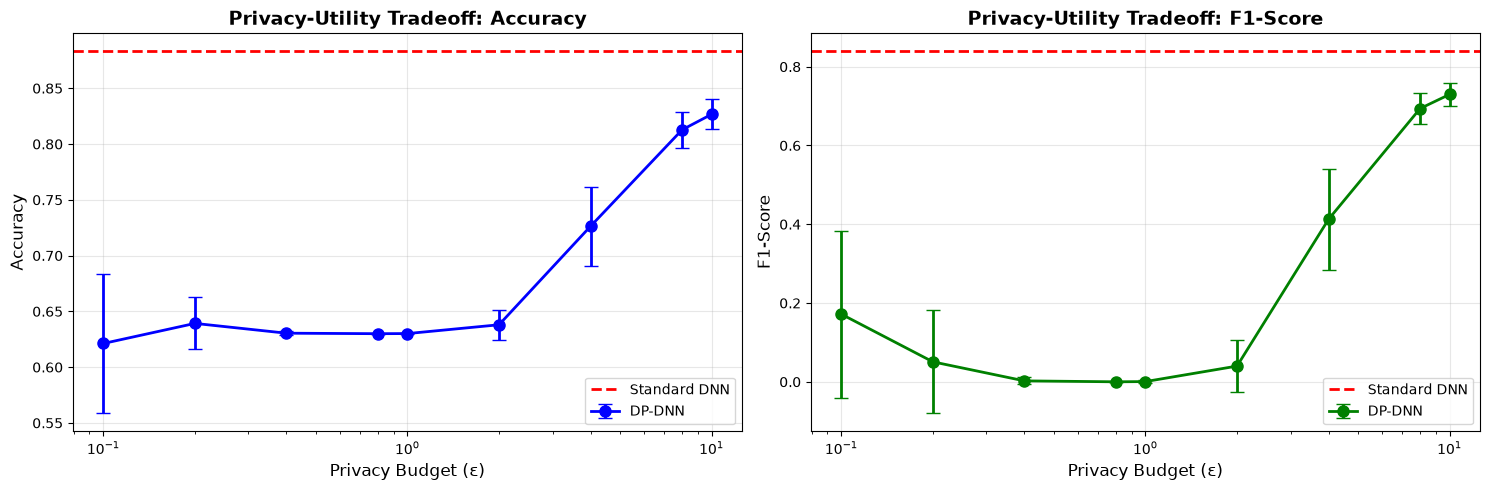

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'],
                 fmt='bo-', capsize=5, linewidth=2, markersize=8, label='DP-DNN')
if baseline_accuracy is not None:
    axes[0].axhline(y=baseline_accuracy, color='r', linestyle='--', linewidth=2, label='Standard DNN')
axes[0].set_xlabel('Privacy Budget (\u03b5)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Privacy-Utility Tradeoff: Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

axes[1].errorbar(results_df['epsilon'], results_df['f1_score_mean'],
                 yerr=results_df['f1_score_std'],
                 fmt='go-', capsize=5, linewidth=2, markersize=8, label='DP-DNN')
if baseline_f1 is not None:
    axes[1].axhline(y=baseline_f1, color='r', linestyle='--', linewidth=2, label='Standard DNN')
axes[1].set_xlabel('Privacy Budget (\u03b5)', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('Privacy-Utility Tradeoff: F1-Score', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('output/dp_dnn_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Summary

In [11]:
print("="*80)
print("DP-DNN EXPERIMENT SUMMARY (CANCER RISK DATASET)")
print("="*80)
print(f"\nPrivacy Mechanism: DP-SGD (Opacus)")
print(f"  - Per-sample gradient clipping (max norm = {max_grad_norm})")
print(f"  - Gaussian noise injection")
print(f"  - R\u00e9nyi DP accounting")
print(f"\nArchitecture: Input({input_size}) -> Dense(64,ReLU) -> Dropout(0.3) -> Dense(32,ReLU) -> Dropout(0.3) -> Output(2)")
print(f"Privacy Budget Range: \u03b5 \u2208 {epsilon_values}")
print(f"Runs per epsilon: {N_RUNS}")
print(f"\nResults saved to output/ directory")
print("="*80)

DP-DNN EXPERIMENT SUMMARY (CANCER RISK DATASET)

Privacy Mechanism: DP-SGD (Opacus)
  - Per-sample gradient clipping (max norm = 1.0)
  - Gaussian noise injection
  - Rényi DP accounting

Architecture: Input(8) -> Dense(64,ReLU) -> Dropout(0.3) -> Dense(32,ReLU) -> Dropout(0.3) -> Output(2)
Privacy Budget Range: ε ∈ [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]
Runs per epsilon: 30

Results saved to output/ directory
